# Multipass DualCache: 四方对比实验

**4 个方法，4 张 GPU 并行**：

| GPU | Method | 说明 |
|:---:|:---|:---|
| 0 | `original` | 原版 DualCache + threshold=0.9 |
| 1 | `plan_a` | 2-pass: 无保底 → 有保底 |
| 2 | `adaptive` | 多遍扫描，每轮按分位数降 threshold |
| 3 | `factor` | 多遍扫描，用 factor 策略，无逐步保底 |

**代码结构**：
- `llada/generate_multipass.py` — 所有新函数（不碰 generate.py）
- `llada/run_multipass.py` — 独立运行脚本
- 本 notebook — 并行启动 + 结果分析

In [1]:
import os
import subprocess
import datetime
import time

os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'

# ===== Config =====
LIMIT = 150
METHODS = [
    ('original', 0),
    ('plan_a',   1),
    ('adaptive', 2),
    ('factor',   7),
]
LOG_DIR = 'nlogs'
RESULT_DIR = 'multipass_results'
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
print(f"Will run {len(METHODS)} methods × {LIMIT} samples on GPUs {[g for _, g in METHODS]}")

Will run 4 methods × 150 samples on GPUs [0, 1, 2, 7]


## 1. 并行启动 4 个方法

In [2]:
os.chdir('llada')

processes = []
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

for method, gpu in METHODS:
    output = f"../{RESULT_DIR}/results_{method}_n{LIMIT}.json"
    log_file = f"../{LOG_DIR}/multipass_{method}_{ts}.log"

    cmd = (f"CUDA_VISIBLE_DEVICES={gpu} python run_multipass.py "
           f"--method {method} --limit {LIMIT} --output {output}")

    print(f"GPU {gpu}: {method} → {output}")
    print(f"  cmd: {cmd}")
    print(f"  log: {log_file}")

    p = subprocess.Popen(cmd, shell=True,
                         stdout=open(log_file, 'w'),
                         stderr=subprocess.STDOUT)
    processes.append((p, method, log_file))

print(f"\n{len(processes)} processes launched, waiting...")

GPU 0: original → ../multipass_results/results_original_n150.json
  cmd: CUDA_VISIBLE_DEVICES=0 python run_multipass.py --method original --limit 150 --output ../multipass_results/results_original_n150.json
  log: ../nlogs/multipass_original_20260212_222109.log
GPU 1: plan_a → ../multipass_results/results_plan_a_n150.json
  cmd: CUDA_VISIBLE_DEVICES=1 python run_multipass.py --method plan_a --limit 150 --output ../multipass_results/results_plan_a_n150.json
  log: ../nlogs/multipass_plan_a_20260212_222109.log
GPU 2: adaptive → ../multipass_results/results_adaptive_n150.json
  cmd: CUDA_VISIBLE_DEVICES=2 python run_multipass.py --method adaptive --limit 150 --output ../multipass_results/results_adaptive_n150.json
  log: ../nlogs/multipass_adaptive_20260212_222109.log
GPU 7: factor → ../multipass_results/results_factor_n150.json
  cmd: CUDA_VISIBLE_DEVICES=7 python run_multipass.py --method factor --limit 150 --output ../multipass_results/results_factor_n150.json
  log: ../nlogs/multipass

In [ ]:
# 等待完成 + 监控进度
import time

while True:
    all_done = True
    for p, method, log_file in processes:
        rc = p.poll()
        if rc is None:
            all_done = False
            # 读最后一行看进度
            try:
                with open(log_file, 'r') as f:
                    lines = f.readlines()
                    last = lines[-1].strip() if lines else "..."
                print(f"  [{method}] running... {last[-80:]}")
            except:
                print(f"  [{method}] running...")
        else:
            print(f"  [{method}] DONE (exit code {rc})")
    print()
    if all_done:
        break
    time.sleep(30)

print("All processes finished!")

  [original] running... ...
  [plan_a] running... ...
  [adaptive] running... ...
  [factor] running... ...

  [factor] running... Loading checkpoint shards: 100%|██████████| 6/6 [00:01<00:00,  4.14it/s]

  [factor] running... Loading checkpoint shards: 100%|██████████| 6/6 [00:01<00:00,  4.14it/s]

  [factor] running... Loading checkpoint shards: 100%|██████████| 6/6 [00:01<00:00,  4.14it/s]



## 2. 加载结果 & 四方对比

In [9]:
import json
import re
import numpy as np
import pandas as pd
from datasets import load_dataset

os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'
ds = load_dataset("gsm8k", "main", split="test")


def extract_gsm8k_answer(text):
    """从 GSM8K 格式的文本中提取最终数字答案。"""
    match = re.search(r'####\s*(-?\d[\d,]*\.?\d*)', text)
    if match:
        return match.group(1).replace(',', '')
    numbers = re.findall(r'-?\d[\d,]*\.?\d*', text)
    return numbers[-1].replace(',', '') if numbers else None


# 加载 4 组结果，自动补算精度
data = {}
for method, _ in METHODS:
    path = f"../{RESULT_DIR}/results_{method}_n{LIMIT}.json"
    try:
        with open(path, 'r') as f:
            d = json.load(f)
        # 兼容旧格式：如果没有 correct 字段，从 answer 和 gt 自动补算
        for r in d['results']:
            if 'correct' not in r:
                idx = r['idx']
                gt_answer = extract_gsm8k_answer(ds[idx]['answer'])
                pred_answer = extract_gsm8k_answer(r.get('answer', ''))
                r['gt'] = gt_answer
                r['pred'] = pred_answer
                r['correct'] = (pred_answer is not None and gt_answer is not None
                                and pred_answer.strip() == gt_answer.strip())
        data[method] = d
        acc = sum(r['correct'] for r in d['results']) / len(d['results']) * 100
        print(f"✅ Loaded {method}: {len(d['results'])} samples, acc={acc:.1f}%")
    except FileNotFoundError:
        print(f"❌ {path} not found — skipping")

methods_loaded = list(data.keys())
n = min(len(data[m]['results']) for m in methods_loaded)
print(f"\n{len(methods_loaded)} methods loaded, {n} samples each")

✅ Loaded original: 150 samples, acc=70.0%
✅ Loaded plan_a: 150 samples, acc=70.0%
✅ Loaded adaptive: 150 samples, acc=22.7%
✅ Loaded factor: 150 samples, acc=58.0%

4 methods loaded, 150 samples each


In [10]:
# ===== NFE + Accuracy 四方对比 =====
nfe_data = {m: [data[m]['results'][i]['nfe'] for i in range(n)] for m in methods_loaded}
acc_data = {}
for m in methods_loaded:
    corrects = [data[m]['results'][i].get('correct', False) for i in range(n)]
    acc_data[m] = sum(corrects) / n * 100

print(f"{'='*75}")
print(f"NFE + ACCURACY COMPARISON ({n} samples)")
print(f"{'='*75}")
print(f"  {'Method':<15} {'Acc%':>7} {'Mean NFE':>9} {'Med NFE':>9} {'Min':>5} {'Max':>5} {'vs orig':>10}")
print("-" * 75)

orig_mean = np.mean(nfe_data['original']) if 'original' in nfe_data else 0
for m in methods_loaded:
    nfes = nfe_data[m]
    diff = np.mean(nfes) - orig_mean if orig_mean > 0 else 0
    acc = acc_data.get(m, 0)
    print(f"  {m:<15} {acc:6.1f}% {np.mean(nfes):9.1f} {np.median(nfes):9.0f} "
          f"{min(nfes):5d} {max(nfes):5d} {diff:+10.1f}")
print(f"{'='*75}")

# Per-sample table
rows = []
for i in range(n):
    row = {'sample': i}
    for m in methods_loaded:
        r = data[m]['results'][i]
        row[f'{m}_nfe'] = r['nfe']
        row[f'{m}_ok'] = '✓' if r.get('correct') else '✗'
    rows.append(row)
df = pd.DataFrame(rows)
display(df)

NFE + ACCURACY COMPARISON (150 samples)
  Method             Acc%  Mean NFE   Med NFE   Min   Max    vs orig
---------------------------------------------------------------------------
  original          70.0%      84.7        86    27   136       +0.0
  plan_a            70.0%      93.3        94    33   148       +8.7
  adaptive          22.7%      27.3        23    18    62      -57.4
  factor            58.0%      78.7        79    22   156       -6.0


,sample,original_nfe,original_ok,plan_a_nfe,plan_a_ok,adaptive_nfe,adaptive_ok,factor_nfe,factor_ok
0,0,115,✓,124,✓,48,✓,100,✓
1,1,76,✗,72,✗,49,✓,69,✓
2,2,103,✗,97,✗,38,✗,113,✗
3,3,105,✓,148,✓,37,✓,112,✓
4,4,95,✓,103,✓,20,✗,85,✓
...,...,...,...,...,...,...,...,...,...
145,145,91,✓,98,✓,44,✗,77,✗
146,146,66,✓,69,✓,24,✗,63,✓
147,147,120,✗,128,✗,20,✗,99,✗
148,148,90,✗,108,✓,46,✓,70,✗


## 3. 多遍方法的 pass 级分析（Adaptive & Factor）

In [11]:
from collections import defaultdict

for method_name in ['adaptive', 'factor']:
    if method_name not in data:
        continue

    print(f"\n{'='*70}")
    print(f"{method_name.upper()} — Per-pass Aggregate")
    print(f"{'='*70}")

    pass_agg = defaultdict(lambda: {
        'count': 0, 'unmasked': [], 'nfe': [], 'remaining': [], 'thresholds': []
    })

    for r in data[method_name]['results'][:n]:
        passes = r['stats'].get('passes', [])
        for p in passes:
            k = p['pass']
            pass_agg[k]['count'] += 1
            pass_agg[k]['unmasked'].append(p['unmasked'])
            pass_agg[k]['nfe'].append(p['nfe'])
            pass_agg[k]['remaining'].append(p['remaining_before'])
            if 'threshold' in p:
                pass_agg[k]['thresholds'].append(p['threshold'])

    # Header depends on method
    if method_name == 'adaptive':
        print(f"  {'Pass':<5} {'Count':<7} {'Avg τ':<8} {'Avg unmask':<12} "
              f"{'Avg NFE':<9} {'Avg remain':<12}")
    else:
        print(f"  {'Pass':<5} {'Count':<7} {'Avg unmask':<12} "
              f"{'Avg NFE':<9} {'Avg remain':<12}")
    print("-" * 60)

    for k in sorted(pass_agg.keys()):
        pa = pass_agg[k]
        line = f"  {k:<5} {pa['count']:<7} "
        if method_name == 'adaptive' and pa['thresholds']:
            line += f"{np.mean(pa['thresholds']):<8.4f} "
        line += (f"{np.mean(pa['unmasked']):<12.1f} "
                 f"{np.mean(pa['nfe']):<9.1f} "
                 f"{np.mean(pa['remaining']):<12.1f}")
        print(line)

    # 平均 pass 数和 NFE
    num_passes = [r['stats'].get('num_passes', len(r['stats'].get('passes', [])))
                  for r in data[method_name]['results'][:n]]
    total_nfes = [r['nfe'] for r in data[method_name]['results'][:n]]
    print(f"\n  Avg passes: {np.mean(num_passes):.1f}  |  Avg total NFE: {np.mean(total_nfes):.1f}")


ADAPTIVE — Per-pass Aggregate
  Pass  Count   Avg τ    Avg unmask   Avg NFE   Avg remain  
------------------------------------------------------------
  0     150     0.9000   5.8          9.1       256.0       
  1     150     0.2494   228.0        13.8      250.2       
  2     34      0.4915   81.9         9.2       97.9        
  3     16      0.5406   30.6         4.4       33.9        
  4     7       0.5603   6.1          3.0       7.6         
  5     4       0.4440   0.5          1.5       2.5         
  6     4       0.4185   1.2          1.2       2.0         
  7     3       0.3928   0.0          1.0       1.0         
  8     3       0.3928   0.0          1.0       1.0         
  9     3       0.3928   0.0          1.0       1.0         

  Avg passes: 2.5  |  Avg total NFE: 27.3

FACTOR — Per-pass Aggregate
  Pass  Count   Avg unmask   Avg NFE   Avg remain  
------------------------------------------------------------
  0     150     129.3        37.5      256.0       


## 4. 可视化

/data/houpu/tmp/ipykernel_372473/3988799146.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=methods_loaded, patch_artist=True)


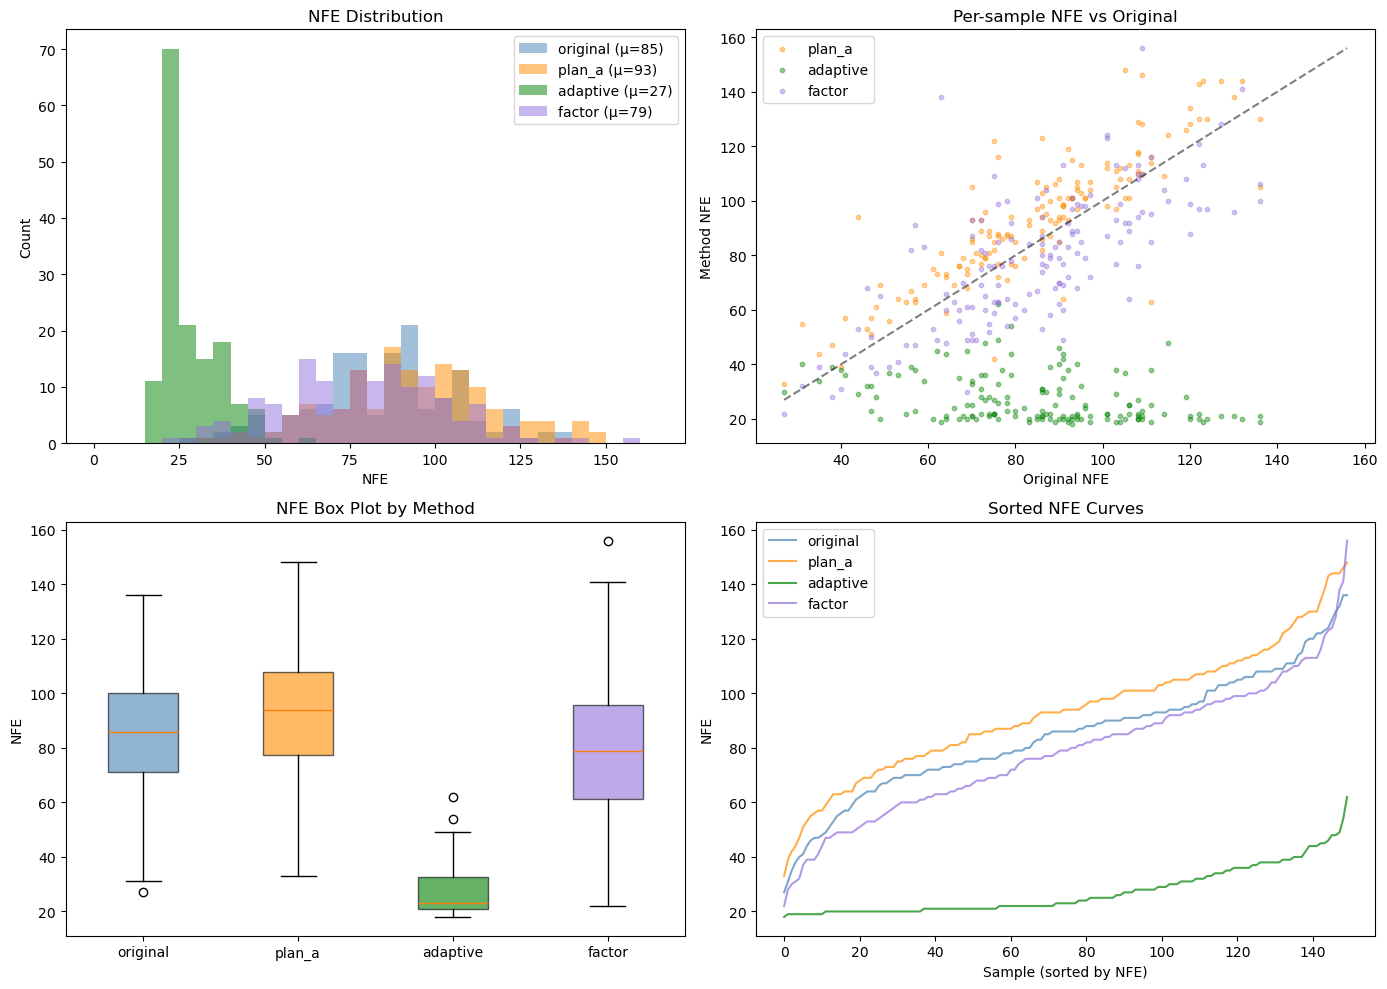

Figure saved to multipass_results/comparison_4way.png


In [12]:
import matplotlib.pyplot as plt

colors = {'original': 'steelblue', 'plan_a': 'darkorange', 'adaptive': 'green', 'factor': 'mediumpurple'}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- (1) NFE 分布 ----
ax = axes[0, 0]
all_nfes = []
for m in methods_loaded:
    nfes = nfe_data[m]
    all_nfes.extend(nfes)
bins = range(0, max(all_nfes) + 10, 5)
for m in methods_loaded:
    ax.hist(nfe_data[m], bins=bins, alpha=0.5, label=f'{m} (μ={np.mean(nfe_data[m]):.0f})',
            color=colors.get(m, 'gray'))
ax.set_xlabel('NFE'); ax.set_ylabel('Count')
ax.set_title('NFE Distribution'); ax.legend()

# ---- (2) Scatter: each method vs original ----
ax = axes[0, 1]
if 'original' in nfe_data:
    orig = nfe_data['original']
    for m in methods_loaded:
        if m == 'original':
            continue
        ax.scatter(orig, nfe_data[m], alpha=0.4, s=10, label=m, color=colors.get(m))
    lo, hi = min(orig), max(max(nfe_data[m]) for m in methods_loaded)
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
    ax.set_xlabel('Original NFE'); ax.set_ylabel('Method NFE')
    ax.set_title('Per-sample NFE vs Original'); ax.legend()

# ---- (3) NFE box plot ----
ax = axes[1, 0]
box_data = [nfe_data[m] for m in methods_loaded]
bp = ax.boxplot(box_data, labels=methods_loaded, patch_artist=True)
for patch, m in zip(bp['boxes'], methods_loaded):
    patch.set_facecolor(colors.get(m, 'gray'))
    patch.set_alpha(0.6)
ax.set_ylabel('NFE')
ax.set_title('NFE Box Plot by Method')

# ---- (4) Per-sample sorted NFE ----
ax = axes[1, 1]
for m in methods_loaded:
    sorted_nfes = sorted(nfe_data[m])
    ax.plot(range(len(sorted_nfes)), sorted_nfes, label=m, color=colors.get(m), alpha=0.7)
ax.set_xlabel('Sample (sorted by NFE)'); ax.set_ylabel('NFE')
ax.set_title('Sorted NFE Curves'); ax.legend()

plt.tight_layout()
plt.savefig(f'../{RESULT_DIR}/comparison_4way.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {RESULT_DIR}/comparison_4way.png")

## 5. 各方法日志尾部（调试用）

In [ ]:
import glob

log_files = sorted(glob.glob(f"../{LOG_DIR}/multipass_*.log"), key=os.path.getmtime, reverse=True)
for lf in log_files[:8]:
    print(f"\n--- {os.path.basename(lf)} ---")
    with open(lf, 'r') as f:
        lines = f.readlines()
        for line in lines[-5:]:
            print(f"  {line.rstrip()}")